# Exemple

Introduction

L’objectif de ce travail est de comprendre la structure d’une base de connaissances extraite automatiquement depuis des textes bruts. Le fichier JSON est organisé autour d’events, c’est-à-dire d’événements détectés par la technologie. Chaque event est représenté comme un sous-graphe contenant des nodes et des edges. L’analyse porte d’abord sur la structure générale de la base, puis sur un focus particulier, ici la représentation de la temporalité.

Comprendre la structure du JSON

Quand on lit le JSON, on voit qu’il est organisé autour d’events extraits depuis des textes. Chaque event est un objet principal contenant un type, un context, un sourceNodeId, une liste de nodes et une liste de edges. Les nodes représentent les éléments extraits, tandis que les edges représentent les relations entre ces éléments. Les labels servent à catégoriser les nodes selon leur nature sémantique. On comprend donc que le JSON décrit chaque event comme un mini-graphe structuré, et non comme une simple donnée isolée.

Le champ context ne contient pas le texte complet. Il correspond uniquement à l’endroit ou à l’extrait associé à l’event. Les graphes sont construits événement par événement, ce qui signifie que chaque event correspond à un sous-graphe autonome.

# Importer les bibliothèques et définir le fichier

In [2]:
import json
from collections import Counter

FILE_PATH = "export.events.json"

with open(FILE_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Fichier chargé")
print("Nombre d'events :", len(data))

Fichier chargé
Nombre d'events : 11948


# Nombre total d’événements

Ce code compte combien de fois chaque champ apparaît dans les events du dataset. Il permet de distinguer les champs systématiques des champs partiels.

In [3]:
total_events = len(data)
print("Nombre total d'événements :", total_events)

Nombre total d'événements : 11948


La base contient 11 948 events. Cela montre que le dataset est suffisamment volumineux pour permettre une analyse exploratoire pertinente de la structure des sous-graphes.

# Présence des champs dans les events

Pour chaque événement, le nombre de nœuds et le nombre d’arêtes, en fait la moyenne sur l’ensemble du dataset.

In [4]:
field_counter = Counter()

for event in data:
    for field in event.keys():
        field_counter[field] += 1

print("Présence des champs :")
for field, count in field_counter.items():
    print(f"- {field}: {count}")

Présence des champs :
- _id: 11948
- createdAt: 11948
- type: 11948
- subdomain: 4036
- risk: 4323
- riskCarac: 2540
- sourceNodeId: 11948
- context: 11945
- resultAnalyseId: 11948
- taskId: 11948
- nodes: 11948
- edges: 11948
- _class: 11948
- endAt: 3977
- domain: 3603
- startAt: 2677
- location: 759


Certains champs sont présents dans tous les events, comme _id, createdAt, type, sourceNodeId, nodes ou edges. Ils constituent donc la structure de base du modèle de données. D’autres champs apparaissent seulement dans une partie du dataset, comme subdomain, risk, domain, startAt, endAt ou location. Cela signifie que toutes les informations ne sont pas renseignées de manière uniforme selon les événements. On peut donc en déduire qu’une partie des champs est optionnelle, ou qu’elle dépend du type d’event extrait.

# Analyse de la structure des sous-graphes

Ce code répartit les events selon leur nombre de nodes et leur nombre de edges. Il permet donc de décrire la forme générale des sous-graphes présents dans le JSON.

In [5]:
node_distribution = {
    "0_node": 0,
    "1_node": 0,
    "2_3_nodes": 0,
    "more_than_3_nodes": 0
}

edge_distribution = {
    "0_edge": 0,
    "1_edge": 0,
    "more_than_1_edge": 0
}

for event in data:
    nb_nodes = len(event.get("nodes", []))
    nb_edges = len(event.get("edges", []))

    if nb_nodes == 1:
        node_distribution["1_node"] += 1
    elif 2 <= nb_nodes <= 3:
        node_distribution["2_3_nodes"] += 1
    elif nb_nodes > 3:
        node_distribution["more_than_3_nodes"] += 1

    if nb_edges == 0:
        edge_distribution["0_edge"] += 1
    elif nb_edges == 1:
        edge_distribution["1_edge"] += 1
    elif nb_edges > 1:
        edge_distribution["more_than_1_edge"] += 1

print("Répartition du nombre de nodes :")
for k, v in node_distribution.items():
    print(f"- {k}: {v}")

print("\nRépartition du nombre de edges :")
for k, v in edge_distribution.items():
    print(f"- {k}: {v}")

Répartition du nombre de nodes :
- 0_node: 0
- 1_node: 2608
- 2_3_nodes: 5037
- more_than_3_nodes: 4303

Répartition du nombre de edges :
- 0_edge: 2607
- 1_edge: 1474
- more_than_1_edge: 7867


La majorité des events contient soit 2 à 3 nodes (5037), soit plus de 3 nodes (4303). Cela montre que beaucoup de sous-graphes ont une structure relativement riche, et ne se limitent pas à un seul élément isolé. On observe aussi que 2608 events n’ont qu’un seul node, ce qui correspond à des structures très simples.

Du côté des edges, 7867 events ont plus d’une relation, ce qui confirme que la majorité des sous-graphes contient une vraie organisation relationnelle. En revanche, 2607 events n’ont aucun edge, ce qui signifie qu’une partie non négligeable des événements est représentée sans relation explicite entre les éléments. Cela n’indique pas forcément une erreur, mais montre que certains sous-graphes sont beaucoup plus pauvres que d’autres en information relationnelle.

# Construction d’un tableau d’analyse des events par date et type

Ce code construit un tableau simplifié à partir du JSON. Pour chaque event, il récupère la date createdAt et le type, puis ajoute une colonne day afin de faciliter l’analyse journalière des events.

In [44]:
import json
import pandas as pd

FILE_PATH = "export.events.json"

with open(FILE_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []

for i, event in enumerate(data):
    created_at = None
    if "createdAt" in event and isinstance(event["createdAt"], dict):
        created_at = event["createdAt"].get("$date")

    if not created_at:
        continue

    rows.append({
        "event_index": i,
        "createdAt": created_at,
        "type": event.get("type", "UNKNOWN")
    })

df_type = pd.DataFrame(rows)
df_type["createdAt"] = pd.to_datetime(df_type["createdAt"], errors="coerce", utc=True)
df_type = df_type.dropna(subset=["createdAt"])
df_type["day"] = df_type["createdAt"].dt.strftime("%Y-%m-%d")

print(df_type.head())
print("Nombre de lignes :", len(df_type))

   event_index                        createdAt  \
0            0 2026-02-10 13:43:03.827000+00:00   
1            1 2026-02-10 13:43:05.544000+00:00   
2            2 2026-02-10 13:43:05.544000+00:00   
3            3 2026-02-10 13:43:05.544000+00:00   
4            4 2026-02-10 13:43:05.544000+00:00   

                                                type         day  
0                           Thing/Abstract/Event/Win  2026-02-10  
1  Thing/Abstract/Event/Transfer/TransferOfUnbias...  2026-02-10  
2  Thing/Abstract/Event/Transfer/TransferOfUnbias...  2026-02-10  
3                         Thing/Abstract/Event/Build  2026-02-10  
4                      Thing/Abstract/Event/Addition  2026-02-10  
Nombre de lignes : 11948


Le tableau a bien été construit avec 11 948 lignes, soit une ligne par event du JSON. Chaque event est ici associé à sa date createdAt, à son type et au jour correspondant dans la colonne day. Cette structure est adaptée à une analyse temporelle simple, car elle permet de compter les events par jour puis d’identifier les types dominants lors des jours de pic.

# Compter les events par jour

Répartition journalière des events enregistrés pour chaque jour à partir de la colonne day

In [49]:
daily_counts = (
    df_type.groupby("day")
    .size()
    .reset_index(name="event_count")
)

print(daily_counts)
print("Nombre de jours :", len(daily_counts))

           day  event_count
0   2026-02-10         1122
1   2026-02-11         1077
2   2026-02-12         1042
3   2026-02-13          993
4   2026-02-14          639
5   2026-02-15          549
6   2026-02-16          445
7   2026-02-18          851
8   2026-02-19          913
9   2026-02-20          996
10  2026-02-21          716
11  2026-02-22          635
12  2026-02-23          903
13  2026-02-24          874
14  2026-02-25          193
Nombre de jours : 15


Le tableau montre la distribution quotidienne des events sur 15 jours distincts. Les volumes les plus élevés se situent au début de la période, avec 1122 events le 10 février 2026, 1077 le 11 février et 1042 le 12 février. On observe ensuite des variations selon les jours, avec des niveaux plus faibles en fin de période, notamment 193 events le 25 février 2026. Cette vue journalière permet d’identifier les jours où l’activité est la plus forte, ce qui servira ensuite à analyser quels types d’events dominent ces pics.

# Identification des jours de pic

Trie les jours par nombre d’events décroissant et conserve les 3 jours les plus chargés.

In [47]:
top_days = daily_counts.sort_values("event_count", ascending=False).head(3)
print(top_days)

          day  event_count
0  2026-02-10         1122
1  2026-02-11         1077
2  2026-02-12         1042


Les trois jours de pic sont le 10 février 2026 avec 1122 events, le 11 février 2026 avec 1077 events et le 12 février 2026 avec 1042 events. Cela montre que l’activité est particulièrement concentrée au début de la période observée. L’étape suivante consiste à regarder quels types d’events dominent pendant ces jours de forte activité.

# Types d’events dominants sur les jours de pic

Ce code affiche, pour chacun des jours de pic, les types d’events les plus fréquents. Il permet ainsi de relier les pics journaliers à des familles d’événements dominantes.

In [48]:
top_day_labels = top_days["day"].tolist()

for day_label in top_day_labels:
    print(f"\nJour : {day_label}")
    
    top_types = (
        df_type[df_type["day"] == day_label]["type"]
        .value_counts()
        .head(10)
    )
    
    print(top_types)


Jour : 2026-02-10
type
Thing/Abstract/Event/Transfer/TransferOfUnbiasedInformation    117
Thing/Abstract/Event/Own                                        86
Thing/Abstract/Event/Partof                                     69
Thing/Abstract/Event/Addition                                   64
Thing/Abstract/Event/Unknown                                    59
Thing/Abstract/Event                                            58
Thing/Abstract/Event/Engender                                   48
Thing/Abstract/Event/Discover                                   47
Thing/Abstract/Event/Move                                       20
Thing/Abstract/Event/Transfer                                   18
Name: count, dtype: int64

Jour : 2026-02-11
type
Thing/Abstract/Event/Own                                       115
Thing/Abstract/Event/Transfer/TransferOfUnbiasedInformation     92
Thing/Abstract/Event/Addition                                   81
Thing/Abstract/Event/Unknown                           

Les trois jours de pic présentent des profils assez proches. On retrouve principalement les types Thing/Abstract/Event/Own, Thing/Abstract/Event/Transfer/TransferOfUnbiasedInformation, Thing/Abstract/Event/Addition et Thing/Abstract/Event/Unknown. Cela montre que les pics d’activité ne sont pas provoqués par un seul type d’événement isolé, mais plutôt par la forte récurrence de quelques grandes catégories sémantiques. La présence répétée de Unknown indique aussi qu’une partie non négligeable des events de pic reste catégorisée de manière imprécise.

# Histogramme des types dominants sur les jours de pic

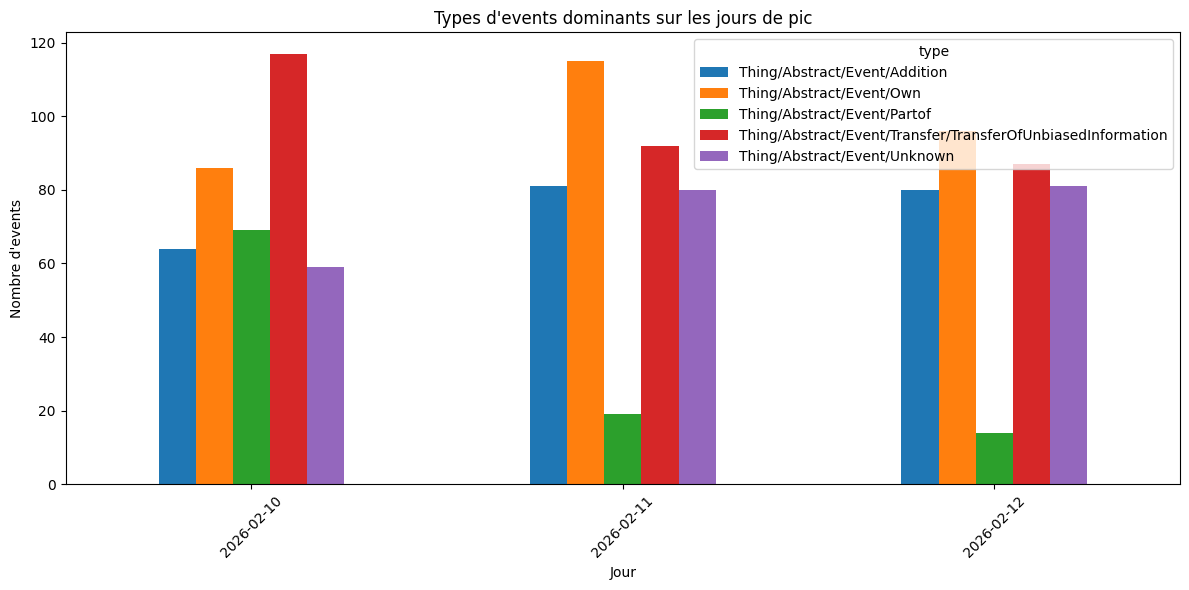

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# On garde les jours de pic
top_day_labels = top_days["day"].tolist()

# On filtre les events de ces jours
df_peak = df_type[df_type["day"].isin(top_day_labels)].copy()

# On compte les types par jour
type_day_counts = (
    df_peak.groupby(["day", "type"])
    .size()
    .reset_index(name="count")
)

# On garde les 5 types les plus fréquents au total sur les jours de pic
top_types_global = (
    type_day_counts.groupby("type")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

type_day_counts = type_day_counts[type_day_counts["type"].isin(top_types_global)]

# Mise en forme pour le graphique
pivot_df = type_day_counts.pivot(index="day", columns="type", values="count").fillna(0)

# Graphique
pivot_df.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Jour")
plt.ylabel("Nombre d'events")
plt.title("Types d'events dominants sur les jours de pic")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

L’histogramme des types montre que les jours de pic sont principalement portés par quelques catégories récurrentes, notamment Transfer/TransferOfUnbiasedInformation, Own, Addition et Unknown. Cela suggère que les pics de volume ne correspondent pas à un phénomène isolé, mais à la répétition de certaines familles d’events.


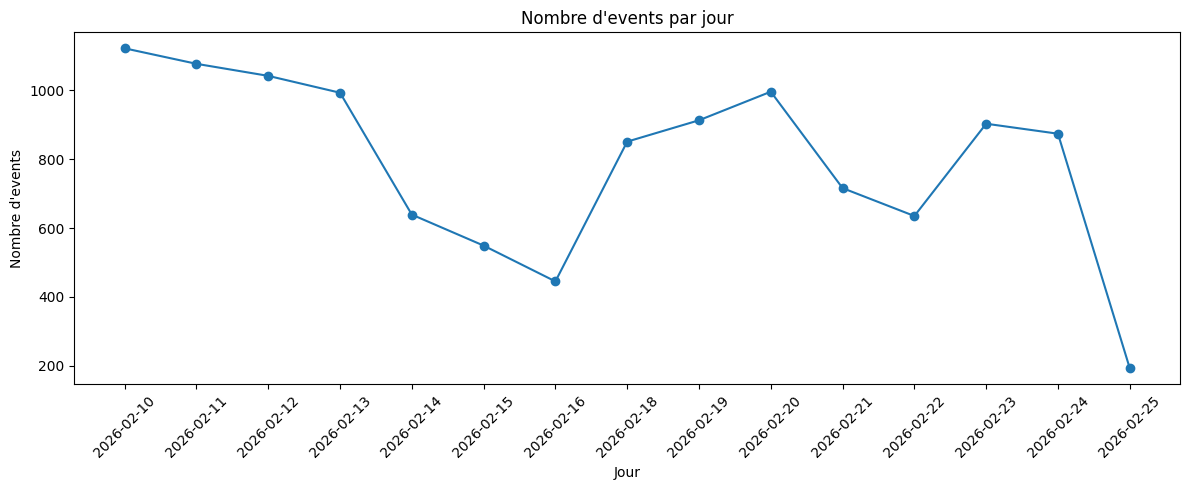

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(daily_counts["day"], daily_counts["event_count"], marker="o")
plt.xlabel("Jour")
plt.ylabel("Nombre d'events")
plt.title("Nombre d'events par jour")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La courbe journalière met en évidence un premier pic entre le 10 et le 12 février 2026, puis une baisse avant une nouvelle remontée autour du 20 février.

# Test

In [1]:
import json
from collections import Counter

FILE_PATH = "/Users/akkouh/Desktop/export.events.fused.json"

with open(FILE_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Fichier chargé")
print("Nombre d'events :", len(data))

Fichier chargé
Nombre d'events : 11948


In [2]:
from collections import Counter
import pandas as pd
from IPython.display import display, Markdown

pair_counter = Counter()

for event in data:
    for node in event.get("nodes", []):
        form = str(node.get("form", "")).strip()
        labels = tuple(sorted(node.get("labels", [])))  # tuple pour pouvoir compter

        pair_counter[(form, labels)] += 1

rows = []
for (form, labels), count in pair_counter.items():
    rows.append({
        "form": form,
        "labels": list(labels),
        "labels_str": " | ".join(labels),
        "count": count
    })

df_top_form_labels = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)

display(Markdown("## Top des couples `form + labels`"))
display(df_top_form_labels.head(20))

print("Nombre total de couples distincts :", len(df_top_form_labels))

## Top des couples `form + labels`

,form,labels,labels_str,count
0,et,[Thing/Abstract/Event/Addition],Thing/Abstract/Event/Addition,934
1,son,[Thing/Abstract/Event/Own],Thing/Abstract/Event/Own,353
2,sa,[Thing/Abstract/Event/Own],Thing/Abstract/Event/Own,215
3,ses,[Thing/Abstract/Event/Own],Thing/Abstract/Event/Own,191
4,annoncé,[Thing/Abstract/Event/Transfer/TransferOfUnbia...,Thing/Abstract/Event/Transfer/TransferOfUnbias...,152
5,découvertes,[Thing/Abstract/Event/Discover],Thing/Abstract/Event/Discover,147
6,de,[Thing/Abstract/Event/Partof],Thing/Abstract/Event/Partof,136
7,leur,[Thing/Abstract/Event/Own],Thing/Abstract/Event/Own,125
8,0000-01-01T00:00,[Thing/Abstract/Time/TimeMin],Thing/Abstract/Time/TimeMin,115
9,vulnérabilités,[Thing/Abstract],Thing/Abstract,112


Nombre total de couples distincts : 13997


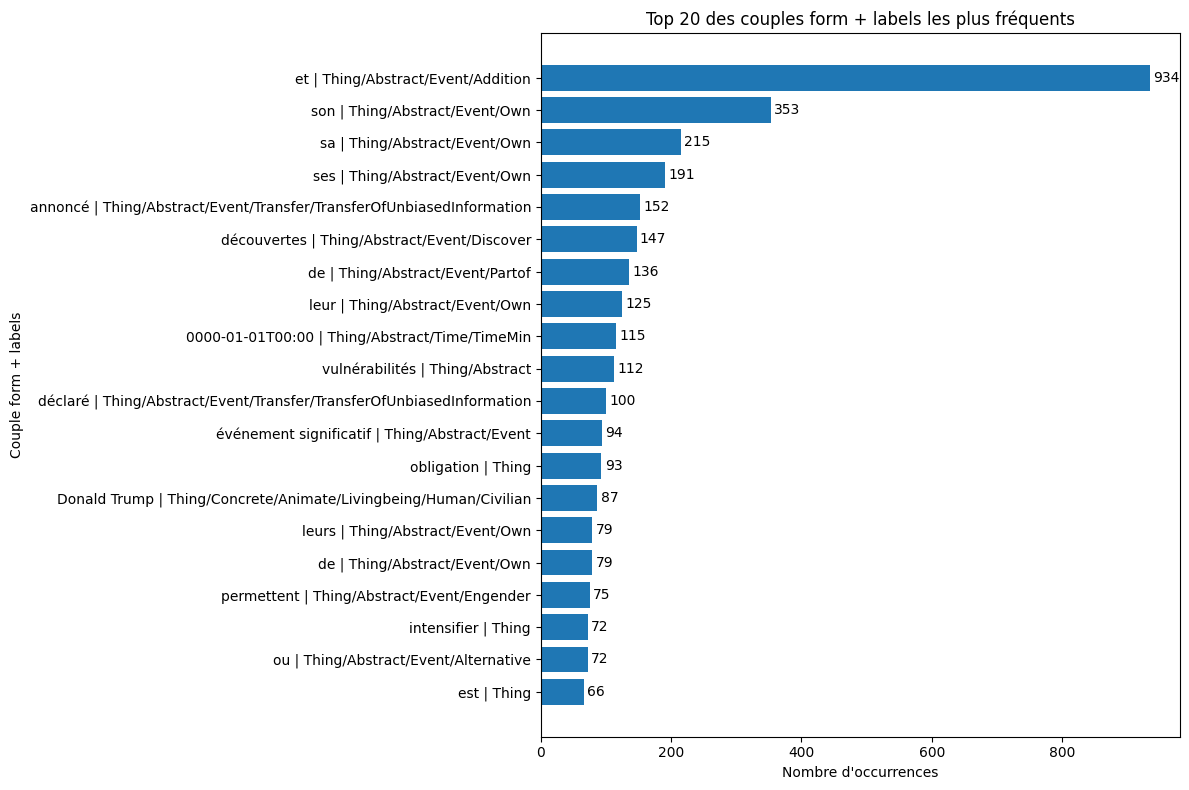

In [3]:
import matplotlib.pyplot as plt

plot_df = df_top_form_labels.head(20).copy()
plot_df["label_display"] = (plot_df["form"] + " | " + plot_df["labels_str"]).apply(
    lambda x: x if len(x) <= 70 else x[:70] + "..."
)

plt.figure(figsize=(12, 8))
bars = plt.barh(plot_df["label_display"][::-1], plot_df["count"][::-1])

plt.xlabel("Nombre d'occurrences")
plt.ylabel("Couple form + labels")
plt.title("Top 20 des couples form + labels les plus fréquents")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va="center"
    )

plt.tight_layout()
plt.show()